In [32]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler


### zad 1

In [33]:
#tworzenie tensorów
x = torch.tensor([[1, 2],
                  [3, 4]])

y = torch.tensor([[5, 6],
                  [7, 8]])

print("Tensor X:\n", x)
print("\nTensor Y:\n", y)

# test dodawania
suma = x + y
print("Dodawanie (X + Y)\n", suma)

# test mnożenia
iloczyn = x * y
print("Mnożenie element po elemencie (X * Y)\n", iloczyn)

#test transpozycji
transpozycja = x.T
print("Transpozycja X\n", transpozycja)

Tensor X:
 tensor([[1, 2],
        [3, 4]])

Tensor Y:
 tensor([[5, 6],
        [7, 8]])
Dodawanie (X + Y)
 tensor([[ 6,  8],
        [10, 12]])
Mnożenie element po elemencie (X * Y)
 tensor([[ 5, 12],
        [21, 32]])
Transpozycja X
 tensor([[1, 3],
        [2, 4]])


Kod działa zgodnie z oczekiwaniami

### zad 2

Epoka: 100, Błąd (Loss): 3.7476
Epoka: 200, Błąd (Loss): 3.7046
Epoka: 300, Błąd (Loss): 3.6884
Epoka: 400, Błąd (Loss): 3.6818
Epoka: 500, Błąd (Loss): 3.6783


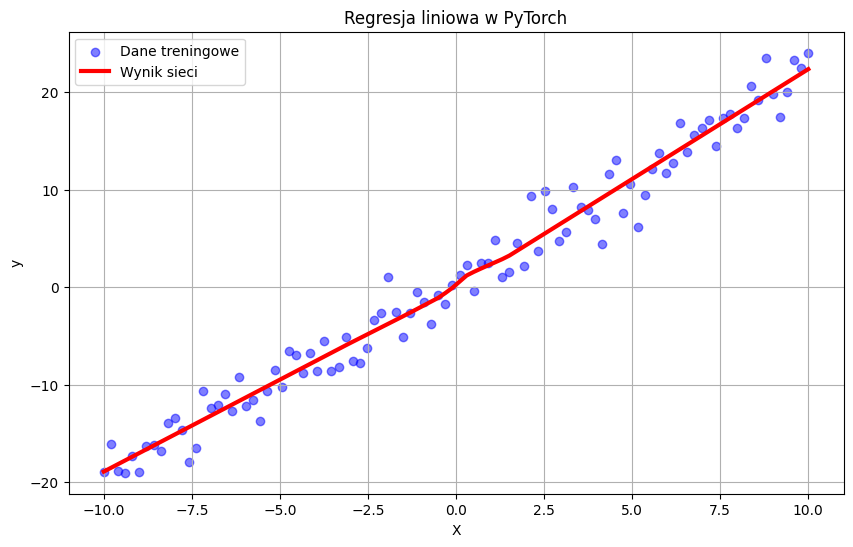

In [34]:
#przygotowywanie danych
X = torch.linspace(-10, 10, 100).view(-1, 1)

#symulacja danych z szumem
y = 2 * X + 1 + torch.randn(X.size()) * 2.0 

#budowa modelu, korzystamy z 8 neuronów
#więcej by przeuczyło model, mniej by "niedouczyło" model
#tworzymy model z jedną warstwą wejściową, jedną ukrytą i jedną wyjściową
model = nn.Sequential(
    nn.Linear(1, 8),    
    nn.ReLU(),          
    nn.Linear(8, 1)     
)

#trening modelu, criterion odpowiada za ocene błędu, a optimizer za redukcje błędu
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.01)
epochs = 500

for epoch in range(epochs):
    #standardowa pętla pytorch
    #reset gradientów
    optimizer.zero_grad() 
    #przewidywanie      
    y_pred = model(X)     
    #błąd    
    loss = criterion(y_pred, y)
    #gradienty wsteczne 
    loss.backward()      
    #aktualizacja wag       
    optimizer.step()           

    if (epoch+1) % 100 == 0:
        print(f'Epoka: {epoch+1}, Błąd (Loss): {loss.item():.4f}')



model.eval()


#wykonujemy predykcje na całym zbiorze, .nograd() odpowiada za brak liczenie pochodnych, co oszczędza pamięć
with torch.no_grad():
    predictions = model(X)


#szkicowanie wykresu
X_numpy = X.numpy()
y_numpy = y.numpy()
pred_numpy = predictions.numpy()


plt.figure(figsize=(10, 6))
plt.scatter(X_numpy, y_numpy, label='Dane treningowe', color='blue', alpha=0.5)
plt.plot(X_numpy, pred_numpy, label='Wynik sieci', color='red', linewidth=3)
plt.title('Regresja liniowa w PyTorch')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

Korzystając z danych syntetycznych model nauczył się prostej zależności regresyjnej

### zad 3

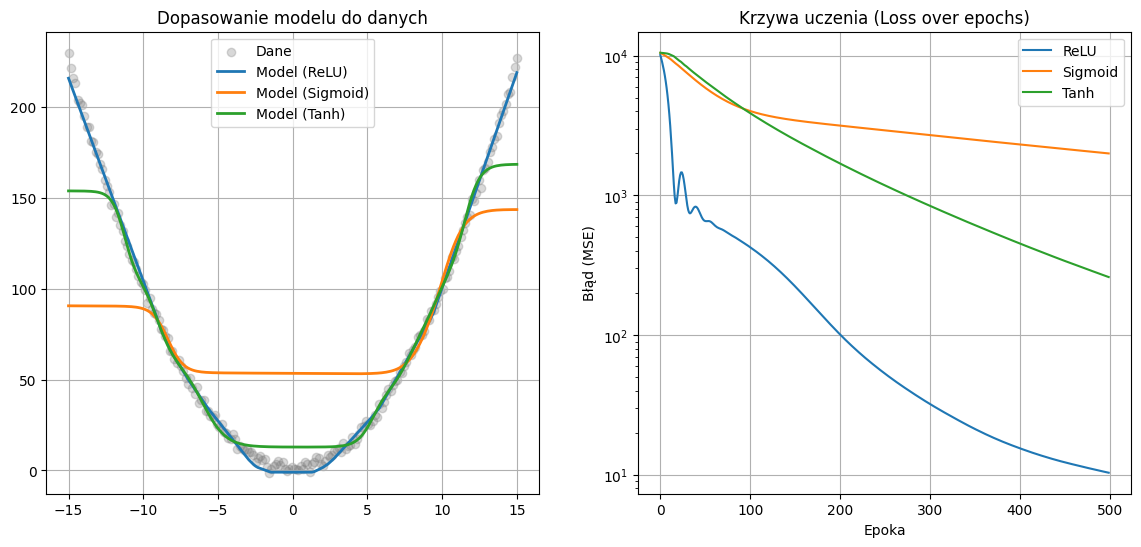

In [35]:
#zwiększenie przedziału, żeby zwizualizować problem
#zmiana funkcji na parabole, żeby przetestować aktywacje dla bardziej skomplikowanego problemu
X = torch.linspace(-15, 15, 200).view(-1, 1)
y = X**2 + 1

#dodajemy szum
y = y + torch.randn(X.size()) * 2.0

#aktywacje do przetestowania
activations = {
    'ReLU': nn.ReLU(),
    'Sigmoid': nn.Sigmoid(),
    'Tanh': nn.Tanh()
}

#wyniki predykcji oraz historia błędów
results = {} #
losses = {}  


#tworzymy pętle po wszystkich fcjach aktywacyjnych
for name, act_func in activations.items():
    
    #model z aktywacją w środku, zwiększono liczbe neuronów
    model = nn.Sequential(
        nn.Linear(1, 20),   
        act_func,           
        nn.Linear(20, 1)
    )
    #korzystamy z Adam ponieważ jest szybszy niż SGD
    optimizer = optim.Adam(model.parameters(), lr=0.05) 
    criterion = nn.MSELoss()
    
    loss_history = []
    
    #przeprowadzamy trening 
    for epoch in range(500):
        optimizer.zero_grad()
        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    
    #zapisujemy wyniki
    results[name] = model(X).detach().numpy()
    losses[name] = loss_history

#wizualizacja błędów
#skorzystano ze skali logarytmicznej dla lepszej wizualizacji błędów
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

ax1.scatter(X.numpy(), y.numpy(), color='gray', alpha=0.3, label='Dane')
for name, pred in results.items():
    ax1.plot(X.numpy(), pred, label=f'Model ({name})', linewidth=2)
ax1.set_title('Dopasowanie modelu do danych')
ax1.legend()
ax1.grid(True)


for name, loss_hist in losses.items():
    ax2.plot(loss_hist, label=f'{name}')
ax2.set_title('Krzywa uczenia (Loss over epochs)')
ax2.set_xlabel('Epoka')
ax2.set_ylabel('Błąd (MSE)')
ax2.set_yscale('log') 
ax2.legend()
ax2.grid(True)

plt.show()

Wyniki pokazują, że w tym zadaniu funkcja ReLU radzi sobie znacznie lepiej niż pozostałe, co jest zgodne z założeniami. Na lewym wykresie widać, że tylko model z ReLU potrafił narysować poprawny kształt łuku, podczas gdy Sigmoid i Tanh stworzyły niemal płaskie linie, ponieważ z natury redukują one wyniki do bardzo małych liczb i nie potrafią osiągnąć wysokich wartości wymaganych w tym zadaniu. Prawy wykres potwierdza to obserwacją, że model z ReLU błyskawicznie zmniejszał swoje błędy, podczas gdy pozostałe dwa przestały się uczyć niemal na samym początku.

### zad 4

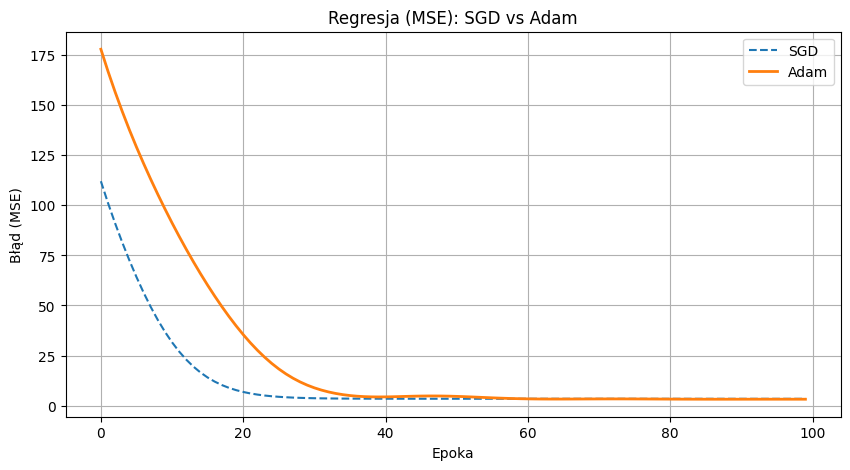

In [36]:
#dane do regresji
X_reg = torch.linspace(-10, 10, 100).view(-1, 1)
y_reg = 2 * X_reg + 1 + torch.randn(X_reg.size()) * 2.0

def train_regression(optimizer_name):
    model = nn.Sequential(nn.Linear(1, 10), nn.ReLU(), nn.Linear(10, 1))
    
    #fcja straty dla regresji
    criterion = nn.MSELoss()
    
    #wybór optymilizatora
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.001)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.02)
        
    losses = []
    
    for epoch in range(100):
        optimizer.zero_grad()
        y_pred = model(X_reg)
        loss = criterion(y_pred, y_reg)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return losses

#uruchomienie programu
loss_sgd_reg = train_regression('SGD')
loss_adam_reg = train_regression('Adam')

#wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(loss_sgd_reg, label='SGD', linestyle='--')
plt.plot(loss_adam_reg, label='Adam', linewidth=2)
plt.title('Regresja (MSE): SGD vs Adam')
plt.xlabel('Epoka')
plt.ylabel('Błąd (MSE)')
plt.legend()
plt.grid(True)
plt.show()

Wykres pokazuje, że Adam wygrał z SGD. Linia Adama spada niemal pionowo w dół, co oznacza, że algorytm ten błyskawicznie nauczył się zadania i zminimalizował błąd już na samym początku. Z kolei linia SGD opada bardzo powoli i łagodnie, co pokazuje, że ten algorytm robi małe kroczki i potrzebowałby znacznie więcej czasu (epok), żeby osiągnąć tak samo dobry wynik jak Adam.

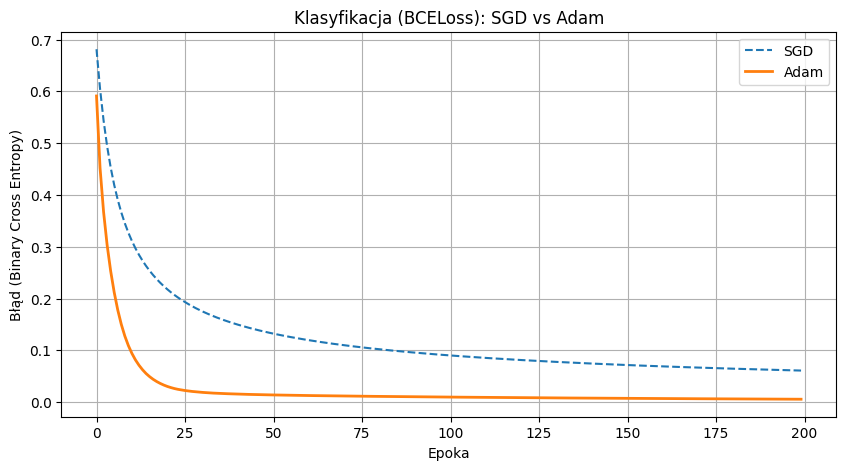

In [37]:
X_cls = torch.linspace(-5, 5, 100).view(-1, 1)
#y=0 dla x<0 i 1 dla x>0
y_cls = (X_cls > 0).float() 

def train_classification(optimizer_name):
    #model do klasyfikacji z sigmoidem
    model = nn.Sequential(
        nn.Linear(1, 10),
        nn.ReLU(),
        nn.Linear(10, 1),
        nn.Sigmoid()  
    )
    
    #funkcja straty dla klasy binarnej
    criterion = nn.BCELoss()
    
    if optimizer_name == 'SGD':
        optimizer = optim.SGD(model.parameters(), lr=0.05)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.05)
    
    losses = []
    
    for epoch in range(200):
        optimizer.zero_grad()
        y_pred = model(X_cls)
        loss = criterion(y_pred, y_cls)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
        
    return losses

#uruchomienie eksperymentu
loss_sgd_cls = train_classification('SGD')
loss_adam_cls = train_classification('Adam')

#wizualizacja
plt.figure(figsize=(10, 5))
plt.plot(loss_sgd_cls, label='SGD', linestyle='--')
plt.plot(loss_adam_cls, label='Adam', linewidth=2)
plt.title('Klasyfikacja (BCELoss): SGD vs Adam')
plt.xlabel('Epoka')
plt.ylabel('Błąd (Binary Cross Entropy)')
plt.legend()
plt.grid(True)
plt.show()

Wykres pokazuje, że również w zadaniu klasyfikacji Adam radzi sobie znacznie sprawniej niż SGD. Linia Adama gwałtownie spada w dół niemal od razu, co oznacza, że błyskawicznie znalazł on moment przejścia między zerem a jedynką i pewnie oddzielił obie klasy. SGD również się uczy, ale robi to wolniej nawet po wielu epokach ma wyższy błąd niż Adam.

### zad 5

In [38]:
#przygotowywanie danych breastcancer jak na poprzednich listach
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train) 
X_test = scaler.transform(X_test)       

X_train_t = torch.tensor(X_train).float()
y_train_t = torch.tensor(y_train).float().view(-1, 1)
X_test_t = torch.tensor(X_test).float()
y_test_t = torch.tensor(y_test).float().view(-1, 1)

#budowa modelu, wejście ma 30 cech, bo tyle jest w datasecie
#ponownie pojawia sie sigmoid dla klasyfikacji binarnej
class BreastCancerNet(nn.Module):
    def __init__(self):
        super(BreastCancerNet, self).__init__()
        self.layer1 = nn.Linear(30, 16) 
        self.relu = nn.ReLU()
        self.layer2 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid() 
        
    def forward(self, x):
        x = self.layer1(x)
        x = self.relu(x)
        x = self.layer2(x)
        x = self.sigmoid(x) 
        return x

model = BreastCancerNet()

#BCE dla klasyfikacji binarnej
criterion = nn.BCELoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

# --- 4. TRENING ---
epochs = 100

for epoch in range(epochs):
    y_pred = model(X_train_t)
    loss = criterion(y_pred, y_train_t)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    



model.eval() 
with torch.no_grad():
    y_pred_test = model(X_test_t)
    
    y_pred_class = y_pred_test.round()
    

    correct_results_sum = (y_pred_class == y_test_t).sum().float()
    acc = correct_results_sum / y_test_t.shape[0]

    print(f"Dokładność (Accuracy): {acc:.4f} ({acc*100:.2f}%)")



Dokładność (Accuracy): 0.9737 (97.37%)


Sieć neuronowa analizuje tutaj 30 ustandaryzowanych cech. Uzyskano bardzo wysoka dokładność.

### zad 6

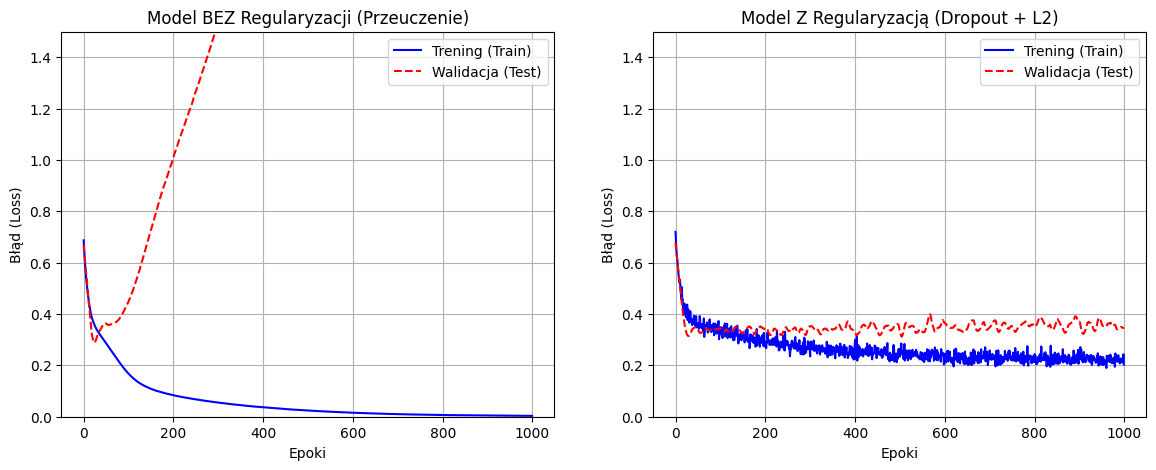

In [39]:
X, y = make_moons(n_samples=100, noise=0.3, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train).view(-1, 1)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test).view(-1, 1)

#funkcja trenująca, w której jest mocno za dużo neuronów
#praktycznie pewne wystąpienie przeuczenia
#regularyzacja wyłącza losowo 50% neuronów

def train_experiment(use_regularization=False):
    layers = []
    layers.append(nn.Linear(2, 200))
    layers.append(nn.ReLU())
    
    if use_regularization:
        layers.append(nn.Dropout(p=0.5)) 
        
    layers.append(nn.Linear(200, 200))
    layers.append(nn.ReLU())
    
    if use_regularization:
        layers.append(nn.Dropout(p=0.5)) 
        
    layers.append(nn.Linear(200, 1))
    layers.append(nn.Sigmoid())
    
    model = nn.Sequential(*layers)
    
    criterion = nn.BCELoss()
    
    # weightdecay to regularyzacja L2
    if use_regularization:
        optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=0.01)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        
    train_losses = []
    val_losses = []
    
    #pętla uczenia, 1000 epok żeby zapewnić przeuczenie
    epochs = 1000 
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred = model(X_train)
        loss = criterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
        

        model.eval()
        with torch.no_grad():
            y_val = model(X_test)
            val_loss = criterion(y_val, y_test)
            val_losses.append(val_loss.item())
            
    return train_losses, val_losses

train_loss_over, val_loss_over = train_experiment(use_regularization=False)
train_loss_reg, val_loss_reg = train_experiment(use_regularization=True)


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))


ax1.plot(train_loss_over, label='Trening (Train)', color='blue')
ax1.plot(val_loss_over, label='Walidacja (Test)', color='red', linestyle='--')
ax1.set_title('Model BEZ Regularyzacji (Przeuczenie)')
ax1.set_xlabel('Epoki')
ax1.set_ylabel('Błąd (Loss)')
ax1.legend()
ax1.grid(True)
ax1.set_ylim(0, 1.5)


ax2.plot(train_loss_reg, label='Trening (Train)', color='blue')
ax2.plot(val_loss_reg, label='Walidacja (Test)', color='red', linestyle='--')
ax2.set_title('Model Z Regularyzacją (Dropout + L2)')
ax2.set_xlabel('Epoki')
ax2.set_ylabel('Błąd (Loss)')
ax2.legend()
ax2.grid(True)
ax2.set_ylim(0, 1.5)

plt.show()

Widzimy klasyczne zjawisko przeuczenia. W przypadku lewego wykresu otrzymujemy wybitne wyniki treningowe, natomiast w trakcie testu błąd jest ogromny. Dzięki dropout oraz regularyzacji L2 otrzymuje znacznie lepsze wyniki testowe.